In [ ]:
!git clone https://github.com/ByteDance-Seed/Depth-Anything-3.git

In [ ]:
!cd Depth-Anything-3

In [ ]:
!pip install torch torchvision opencv-python matplotlib urllib3

In [46]:
import os
import cv2
import zipfile
import urllib.request
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from depth_anything_3.api import DepthAnything3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = (128, 128)
BATCH_SIZE = 8
EPOCHS = 15

print(f"Устройство: {device}")

Устройство: cuda


## 1. Загрузка датасета (Ants vs Bees)

In [47]:
dataset_url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
zip_path = "hymenoptera_data.zip"
data_dir = "hymenoptera_data"

if not os.path.exists(data_dir):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")

def load_images(folder_path, max_images=50):
    images = []
    paths = glob.glob(f"{folder_path}/*.jpg")[:max_images]
    for p in paths:
        img = cv2.imread(p)
        if img is not None:
            img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), IMG_SIZE)
            images.append(img)
    return images

train_ants = load_images(f"{data_dir}/train/ants", 200)
train_bees = load_images(f"{data_dir}/train/bees", 200)
test_ants = load_images(f"{data_dir}/val/ants", 50)
test_bees = load_images(f"{data_dir}/val/bees", 50)

train_rgb = train_ants + train_bees
train_labels = [0]*len(train_ants) + [1]*len(train_bees)

test_rgb = test_ants + test_bees
test_labels = [0]*len(test_ants) + [1]*len(test_bees)

print(f"Итого: {len(train_rgb)} Train картинок, {len(test_rgb)} Test картинок.")

Итого: 243 Train картинок, 100 Test картинок.


## 2. Генерация глубины

In [48]:
da3_model = DepthAnything3(model_name="da3-small").to(device).eval()

def generate_depths(rgb_list):
    depths =[]
    with torch.no_grad():
        for frame in rgb_list:
            pred = da3_model.inference(image=[frame])
            depth = pred.depth[0]
            if isinstance(depth, torch.Tensor):
                depth = depth.cpu().numpy()
                
            depth_norm = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)
            depth_resized = cv2.resize(depth_norm, IMG_SIZE)
            depths.append(depth_resized)
    return depths

print("маски глубины для Train...")
train_depth = generate_depths(train_rgb)
print("маски глубины для Test...")
test_depth = generate_depths(test_rgb)

del da3_model
torch.cuda.empty_cache()

[INFO ] using MLP layer as FFN
маски глубины для Train...
[INFO ] Processed Images Done taking 0.008768796920776367 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.14068245887756348 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0008513927459716797 seconds
[INFO ] Processed Images Done taking 0.006907463073730469 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.09628891944885254 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0008149147033691406 seconds
[INFO ] Processed Images Done taking 0.007063150405883789 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.0928952693939209 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0008292198181152344 seconds
[INFO ] Processed Images Done taking 0.007279634475708008 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 0.08399295806884766 seconds
[INFO ] Conversion to Prediction D

## 3. DataLoader'ы

In [50]:
class RealDataset(Dataset):
    def __init__(self, rgb_list, depth_list, label_list):
        self.rgb = rgb_list
        self.depth = depth_list
        self.labels = label_list
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])
        
    def __len__(self): return len(self.labels)
        
    def __getitem__(self, idx):
        r_tensor = transforms.ToTensor()(self.rgb[idx])
        d_tensor = torch.tensor(self.depth[idx], dtype=torch.float32).unsqueeze(0)
        l_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return r_tensor, d_tensor, l_tensor

train_loader = DataLoader(RealDataset(train_rgb, train_depth, train_labels), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(RealDataset(test_rgb, test_depth, test_labels), batch_size=BATCH_SIZE, shuffle=False)

## 4. Модель

In [51]:
class TinyClassifier(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMG_SIZE[0]//8) * (IMG_SIZE[1]//8), 64), 
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

## 5. Обучение


In [52]:
def train_and_evaluate(model, mode_name, channels_mode):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(EPOCHS):
        model.train()
        for rgb, depth, y in train_loader:
            y = y.to(device)
            if channels_mode == 'rgb': x = rgb.to(device)
            elif channels_mode == 'depth': x = depth.to(device)
            elif channels_mode == 'rgbd': x = torch.cat((rgb, depth), dim=1).to(device)
                
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    all_preds, all_labels = [],[]
    with torch.no_grad():
        for rgb, depth, y in test_loader:
            if channels_mode == 'rgb': x = rgb.to(device)
            elif channels_mode == 'depth': x = depth.to(device)
            elif channels_mode == 'rgbd': x = torch.cat((rgb, depth), dim=1).to(device)
            
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    print(f"{mode_name} -> Accuracy: {acc*100:.1f}%")
    return acc

## 6. Эксперименты и Выводы

Только RGB -> Accuracy: 62.0%
Только Depth -> Accuracy: 50.0%
RGB-D (Склейка) -> Accuracy: 67.0%


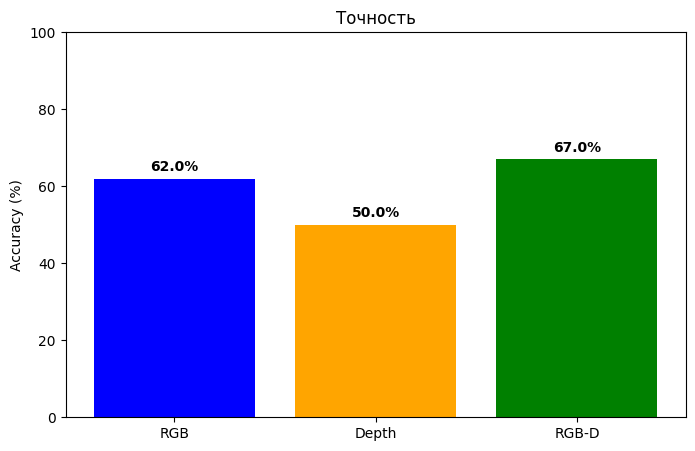

In [55]:
# 1. RGB
acc_rgb = train_and_evaluate(TinyClassifier(in_channels=3), "Только RGB", "rgb")
# 2. Depth
acc_depth = train_and_evaluate(TinyClassifier(in_channels=1), "Только Depth", "depth")
# 3. RGB-D
acc_rgbd = train_and_evaluate(TinyClassifier(in_channels=4), "RGB-D (Склейка)", "rgbd")

plt.figure(figsize=(8, 5))
plt.bar(['RGB', 'Depth', 'RGB-D'],[acc_rgb*100, acc_depth*100, acc_rgbd*100], color=['blue', 'orange', 'green'])
plt.ylabel('Accuracy (%)')
plt.title('Точность')
plt.ylim(0, 100)
for i, v in enumerate([acc_rgb, acc_depth, acc_rgbd]):
    plt.text(i, v*100 + 2, f"{v*100:.1f}%", ha='center', fontweight='bold')
plt.show()

Depth Anything 3 - это неплохой инструмент для увеличения качества. Эксперимент показал, что:
DA3 как бесплатный сенсор: получили карту глубины из обычных фото, не имея лидара. Это позволило обучить модель на данных, которых у нас изначально не было.
Профит в точности (+5%): Чистый RGB выдал 62%, а связка RGB + Глубина — 67%. Эти 5% прироста получены за счет того, что геометрия от DA3 помогла маленькой модели отделить объект от сложного фона (травы/земли).
Геометрия vs Цвет: Сама по себе глубина (50%) в этой задаче бесполезна (муравей и пчела по форме почти одинаковы), но как дополнительный канал она работает как подсказка, куда именно модели нужно смотреть.
